**Integrantes**
- Isabel Baungartner
- Julia Leandro
- Lavínia Oliveira
- Maria Eduarda Fonseca


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

#### Lendo base de dados e removendo valores aleatoriamente **executar SEM ALTERAR**

In [ ]:
#Carregando base de dados
penguins = sns.load_dataset('penguins')

np.random.seed(42)  #Definindo seed do random para replicabilidade

#Removendo valores
removidos = set()
porcentagem = 0.30 #Porcentagem (0~1) das células a serem removidas
qtdCelulas = len(penguins)*(len(penguins.columns)) #Quantidade de células na base de dados, ignorando a última coluna

for i in range(int(np.ceil(porcentagem*qtdCelulas))):
  linha = np.random.randint(0, len(penguins))
  coluna = np.random.randint(0, len(penguins.columns))
  while (linha, coluna) in removidos:
    linha = np.random.randint(0, len(penguins))
    coluna = np.random.randint(0, len(penguins.columns))

  penguins.iloc[linha, coluna] = np.nan
  removidos.add((linha,coluna))

penguins.info()
print("\n\nForam removidas",str(len(removidos)), "células das",str(qtdCelulas))
del removidos
del qtdCelulas
del porcentagem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            232 non-null    object 
 1   island             241 non-null    object 
 2   bill_length_mm     233 non-null    float64
 3   bill_depth_mm      244 non-null    float64
 4   flipper_length_mm  247 non-null    float64
 5   body_mass_g        240 non-null    float64
 6   sex                235 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Foram removidas 723 células das 2408


In [ ]:
#Converter o dataset para csv
penguins.to_csv("penguinsnan.csv", index=False)

In [ ]:
penguins_na = pd.read_csv("penguinsnan.csv", header=0, na_values='?')
penguins_na.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,NaN,18.7,NaN,3750.0,Male
1,NaN,NaN,39.5,17.4,186.0,NaN,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,NaN,NaN,19.3,193.0,3450.0,NaN


Cópia do Penguins

In [ ]:
penguinsOriginalNa = penguins.copy()
penguinsOriginalNa

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,NaN,18.7,NaN,3750.0,Male
1,NaN,NaN,39.5,17.4,186.0,NaN,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,NaN,NaN,19.3,193.0,3450.0,NaN
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,NaN,46.8,14.3,215.0,NaN,NaN
341,NaN,Biscoe,NaN,NaN,NaN,5750.0,NaN
342,Gentoo,Biscoe,45.2,14.8,NaN,5200.0,Female


### Filtros para manipular a Imputação de Categorias Categóricas e Categorias Numéricas

In [ ]:
list(penguins.columns)

['species',
 'island',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [ ]:
colunas_numericas = list(penguins.columns)
colunas_numericas.remove('species')
colunas_numericas.remove('sex')
colunas_numericas.remove('island')
colunas_numericas

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [ ]:
colunas_categoricas = list(penguins.columns)
colunas_categoricas.remove('bill_length_mm')
colunas_categoricas.remove('bill_depth_mm')
colunas_categoricas.remove('flipper_length_mm')
colunas_categoricas.remove('body_mass_g')
colunas_categoricas.remove('sex')
colunas_categoricas

['species', 'island']

###Imputação de Colunas Numéricas - KNN Imputer

#### Justificativa - Método KNN

Para preencher os valores ausentes nas colunas numéricas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), optamos por utilizar o método **KNN Imputer (K-Nearest Neighbors)**. Essa técnica preenche os valores faltantes considerando os vizinhos mais próximos.

#####**Por que o KNN Imputer?**

O KNN é mais robusto do que estratégias simples como a média ou a mediana, pois leva em conta o contexto dos dados ao redor do valor nan. Em vez de assumir que todos os registros são parecidos (como faz a média), o KNN analisa registros com características semelhantes, o que resulta em uma imputação mais coerente com o padrão real dos dados.

Usamos o parâmetro `n_neighbors=5`, que considera os 5 registros mais próximos, e `weights='distance'`, o que dá mais peso aos vizinhos mais próximos, tornando a imputação ainda mais precisa.

#####**Por que normalizar?**

Antes de aplicar o KNN, foi necessário **normalizar os dados numéricos com MinMaxScaler**, pois o algoritmo de vizinhos utiliza **distâncias euclidianas** para calcular a proximidade entre registros. Como as colunas estão em escalas diferentes (por exemplo, massa corporal em gramas e comprimento do bico em milímetros), sem a normalização as colunas com valores maiores teriam influência desproporcional.

Após a imputação, aplicamos a **desnormalização** para retornar os valores à sua escala original, garantindo que o DataFrame final mantenha os dados com a mesma interpretação que os dados originais.

####Código de Imputação

In [ ]:
#Cópia do DataFrame original com NANs
penguins_numericas = penguinsOriginalNa.copy()

In [ ]:
#Normalização

#MinMaxScaler: normaliza os dados para o intervalo [0, 1]
#fit(): calcula os valores mínimos e máximos de cada coluna numérica
scaler = MinMaxScaler()
scaler.fit(penguins_numericas[colunas_numericas])
penguins_norm = scaler.transform(penguins_numericas[colunas_numericas])
penguins_norm[:5]

array([[       nan, 0.66666667,        nan, 0.29166667],
       [0.24489796, 0.51190476, 0.21052632,        nan],
       [0.27755102, 0.58333333, 0.36842105, 0.15277778],
       [       nan,        nan,        nan,        nan],
       [       nan, 0.73809524, 0.33333333, 0.20833333]])

In [ ]:
#DataFrame normalizado para imputação
penguins_normDF = pd.DataFrame(penguins_norm, columns=colunas_numericas)

#Ajustando parâmetros
penguins_normDF['species'] = penguins_numericas['species']

penguins_normDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,NaN,0.666667,NaN,0.291667,Adelie
1,0.244898,0.511905,0.210526,NaN,NaN
2,0.277551,0.583333,0.368421,0.152778,Adelie
3,NaN,NaN,NaN,NaN,Adelie
4,NaN,0.738095,0.333333,0.208333,Adelie
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,Gentoo
340,0.542857,0.142857,0.719298,NaN,Gentoo
341,NaN,NaN,NaN,0.847222,NaN
342,0.477551,0.202381,NaN,0.694444,Gentoo


In [ ]:
#KNN

#KNNImputer: preenche valores ausentes com base nos vizinhos mais próximos
#n_neighbors=5, decidindo o k
#weights='distance', para dar mais peso para valores mais próximos
#copy = True,para o imputador fazer uma cópia dos dados ao invés de modificá-los diretamente
#fit(): ajusta o modelo de imputação com os dados normalizados
imputer = KNNImputer(n_neighbors=5, weights='distance', copy=True)
imputer.fit(penguins_normDF[colunas_numericas])

#transform(): realiza a imputação nas colunas numéricas
penguins_normDF[colunas_numericas] = imputer.transform(penguins_normDF[colunas_numericas])
penguins_normDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,0.169388,0.666667,0.105263,0.291667,Adelie
1,0.244898,0.511905,0.210526,0.260212,NaN
2,0.277551,0.583333,0.368421,0.152778,Adelie
3,0.416169,0.483119,0.466297,0.409317,Adelie
4,0.061225,0.738095,0.333333,0.208333,Adelie
...,...,...,...,...,...
339,0.416169,0.483119,0.466297,0.409317,Gentoo
340,0.542857,0.142857,0.719298,0.638889,Gentoo
341,0.678717,0.265306,0.780702,0.847222,NaN
342,0.477551,0.202381,0.754386,0.694444,Gentoo


In [ ]:
#Desnormalização

#inverse_transform(): desfaz a normalização, volta para a escala original
penguins_desnorm = scaler.inverse_transform(penguins_normDF[colunas_numericas]).round(1)
penguins_desnorm[:5]

array([[  37.7,   18.7,  180. , 3750. ],
       [  39.5,   17.4,  186. , 3636.8],
       [  40.3,   18. ,  195. , 3250. ],
       [  43.7,   17.2,  200.6, 4173.5],
       [  35. ,   19.3,  193. , 3450. ]])

In [ ]:
#DF com valores mputados
#Reanexando a coluna 'species'
penguins_numimputDF = pd.DataFrame(penguins_desnorm, columns=colunas_numericas)
penguins_numimputDF['species'] = penguins_normDF['species']

penguins_numimputDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,37.7,18.7,180.0,3750.0,Adelie
1,39.5,17.4,186.0,3636.8,NaN
2,40.3,18.0,195.0,3250.0,Adelie
3,43.7,17.2,200.6,4173.5,Adelie
4,35.0,19.3,193.0,3450.0,Adelie
...,...,...,...,...,...
339,43.7,17.2,200.6,4173.5,Gentoo
340,46.8,14.3,215.0,5000.0,Gentoo
341,50.1,15.3,218.5,5750.0,NaN
342,45.2,14.8,217.0,5200.0,Gentoo


In [ ]:
penguins_numimputDF.to_csv("NumericasImputadas.csv", index=False)
penguins_numimputDF.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,37.7,18.7,180.0,3750.0,Adelie
1,39.5,17.4,186.0,3636.8,NaN
2,40.3,18.0,195.0,3250.0,Adelie
3,43.7,17.2,200.6,4173.5,Adelie
4,35.0,19.3,193.0,3450.0,Adelie


####Comparação - Antes de Imputar vs Depois de Imputar

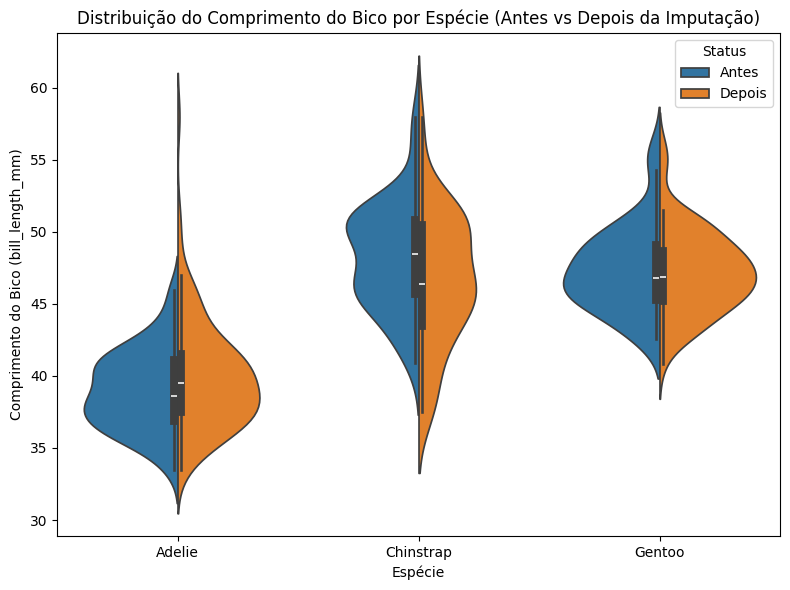

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'bill_length_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'bill_length_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['bill_length_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='bill_length_mm', hue='status', split=True)

plt.title('Distribuição do Comprimento do Bico por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Comprimento do Bico (bill_length_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

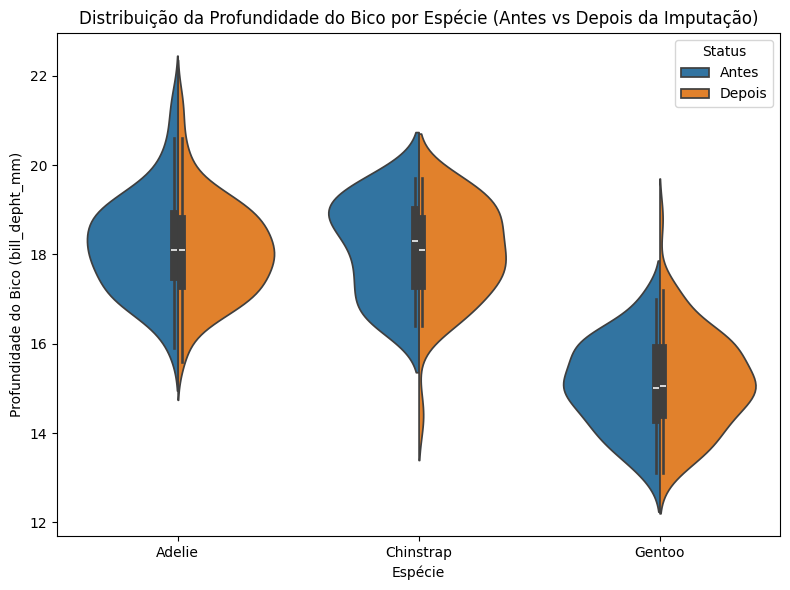

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'bill_depth_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'bill_depth_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['bill_depth_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='bill_depth_mm', hue='status', split=True)

plt.title('Distribuição da Profundidade do Bico por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Profundidade do Bico (bill_depht_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


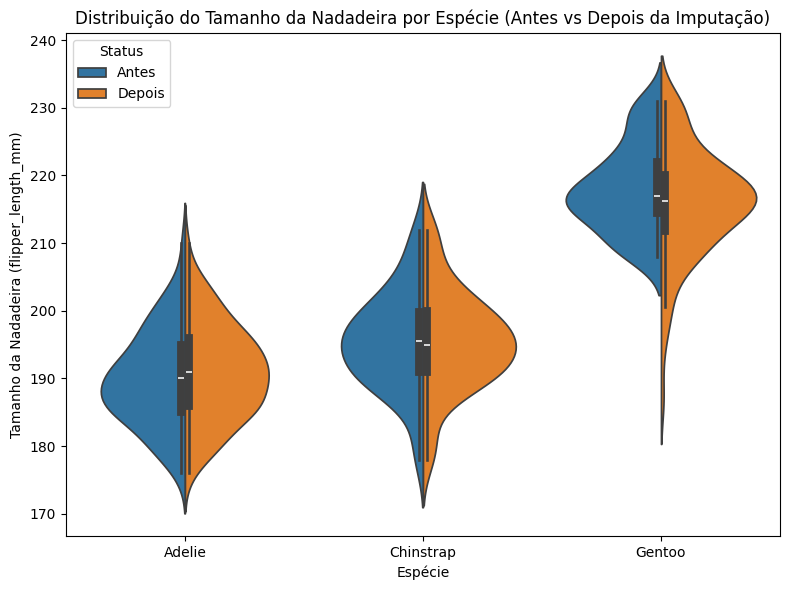

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'flipper_length_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'flipper_length_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['flipper_length_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='flipper_length_mm', hue='status', split=True)

plt.title('Distribuição do Tamanho da Nadadeira por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Tamanho da Nadadeira (flipper_length_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

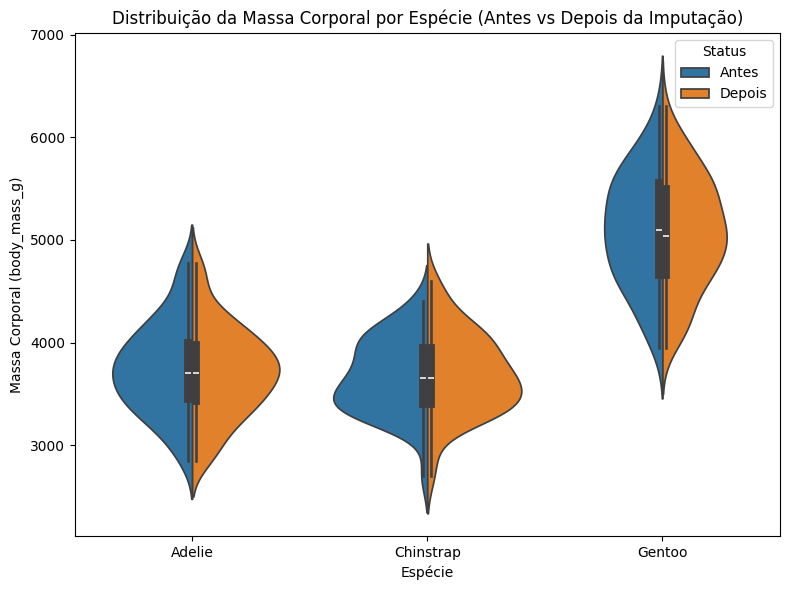

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'body_mass_g']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'body_mass_g']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['body_mass_g'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='body_mass_g', hue='status', split=True)

plt.title('Distribuição da Massa Corporal por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Massa Corporal (body_mass_g)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

###Imputação de Colunas Categóricas - 'Species' e 'Island'

####Justificativa - Método FFILL

Para a imputação das colunas categóricas `species` e `island`, utilizamos o método **`ffill` (forward fill)**, que preenche os valores ausentes com o valor anterior presente na coluna. Essa estratégia foi escolhida com base na suposição de que os dados estavam agrupados de forma ordenada — por exemplo, vários registros seguidos de pinguins da mesma espécie coletados na mesma ilha. Assim, ao preencher com o valor anterior, mantemos uma consistência local que pode refletir a realidade da coleta dos dados.

Essa abordagem é especialmente útil no caso desse dataset, pois existem **relações muito fortes entre a espécie e a ilha** em que o pinguim foi registrado:

- A espécie **Chinstrap** só ocorre na ilha **Dream**.
- A espécie **Gentoo** aparece apenas na ilha **Biscoe**.
- A espécie **Adelie** está presente nas **três ilhas** (Biscoe, Dream e Torgersen).

Portanto, ao usar o preenchimento com `ffill`, é muito provável que o valor anterior represente corretamente tanto a **espécie** quanto a **ilha**, respeitando essa dependência natural entre as colunas. Isso ajuda a **preservar padrões reais do conjunto de dados** e evita a imputação incorreta de valores que não fazem sentido biologicamente ou geograficamente.

Essa técnica é simples, porém eficaz quando os dados estão ordenados de forma coerente, como é o caso neste dataset.

####Código de Imputação

In [ ]:
#Copia o DataFrame com apenas as colunas categóricas
penguins_categoricasDF = penguinsOriginalNa[colunas_categoricas].copy()

In [ ]:
#Método FFILL

#ffill() = forward fill: preenche valores ausentes com o valor anterior da mesma coluna
#Se uma célula está vazia, ela receberá o valor da célula de cima
#Utilizada pois os dados seguem uma sequência
penguins_categoricasDF = penguins_categoricasDF.ffill()

In [ ]:
#DF do resultado após a imputação
penguins_categoricasDF

,species,island
0,Adelie,Torgersen
1,Adelie,Torgersen
2,Adelie,Torgersen
3,Adelie,Torgersen
4,Adelie,Torgersen
...,...,...
339,Gentoo,Biscoe
340,Gentoo,Biscoe
341,Gentoo,Biscoe
342,Gentoo,Biscoe


In [ ]:
penguins_categoricasDF['species'].value_counts()

,count
species,
Adelie,154
Gentoo,124
Chinstrap,66


In [ ]:
penguins_categoricasDF.to_csv("CategoricasImputadas.csv", index=False)

####Comparações

In [ ]:
#Comparação Espécie - Antes
print("Antes")
penguinsOriginalNa['species'].value_counts()

Antes


,count
species,
Adelie,101
Gentoo,82
Chinstrap,49


In [ ]:
#Comparação Espécie - Depois
print("Depois")
penguins_categoricasDF['species'].value_counts()

Depois


,count
species,
Adelie,154
Gentoo,124
Chinstrap,66


In [ ]:
#Comparação Ilha - Antes
print("Antes")
penguinsOriginalNa['island'].value_counts()

Antes


,count
island,
Biscoe,124
Dream,86
Torgersen,31


In [ ]:
#Comparação Ilha - Depois
print("Depois")
penguins_categoricasDF['island'].value_counts()

Depois


,count
island,
Biscoe,169
Dream,124
Torgersen,51


###Imputação Final - Coluna 'Sex'

####Justificativa

Para a imputação dos valores ausentes na coluna `sex`, utilizamos uma estratégia baseada em características biológicas reais dos pinguins. Em muitas espécies, como as do dataset *Penguins*, o **tamanho do bico (bill_depth_mm)** é uma das principais formas de diferenciação entre machos e fêmeas.

**A estratégia adotada foi a seguinte:**

1. **Agrupamos os dados por espécie e sexo** para calcular a **mediana do tamanho do bico** (`bill_depth_mm`) para cada grupo (por exemplo, Adelie/Male, Adelie/Female).
2. Para cada registro com sexo ausente:
   - Verificamos a espécie do pinguim e seu valor de `bill_depth_mm`;
   - Comparamos esse valor com as medianas de `Male` e `Female` dentro da espécie;
   - Atribuímos o sexo correspondente à mediana mais próxima.

Essa abordagem é precisa pois leva em conta uma **característica física importante que tem relação direta com o sexo dos animais**. Além disso, a imputação respeita a variação natural entre espécies, já que cada espécie possui diferentes tamanhos médios de bico entre machos e fêmeas.

Esse método contribui para **preservar a coerência biológica dos dados** e evita distorções que poderiam surgir com métodos mais simples de imputação.

####Código de Imputação

In [ ]:
#Criação de um DataFrame parcial com colunas categóricas (já imputadas)
#e colunas numéricas (já imputadas e desnormalizadas)
#penguins_numimputDF.drop('species', axis=1)], axis=1) -> evitar que species seja duplicada
#Agregar a coluna 'sex' original (ainda com valores ausentes)
penguins_parcial_imput = pd.concat([
    penguins_categoricasDF,
    penguins_numimputDF.drop('species', axis=1)
], axis=1)
penguins_parcial_imput['sex'] = penguinsOriginalNa['sex']

penguins_parcial_imput

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,37.7,18.7,180.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3636.8,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.7,17.2,200.6,4173.5,NaN
4,Adelie,Torgersen,35.0,19.3,193.0,3450.0,NaN
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.7,17.2,200.6,4173.5,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,5000.0,NaN
341,Gentoo,Biscoe,50.1,15.3,218.5,5750.0,NaN
342,Gentoo,Biscoe,45.2,14.8,217.0,5200.0,Female


In [ ]:
# Criar uma cópia do DataFrame original
penguins_completo = penguins_parcial_imput.copy()

In [ ]:
#Calcular as medianas do bill_depth_mm por espécie e sexo
#groupby(): agrupa os dados pelas colunas 'species' e 'sex'
#median(): calcula a mediana da profundidade do bico ('bill_depth_mm') para cada grupo
#unstack(): transforma o segundo nível do índice ('sex') em colunas
#Um DF onde cada linha é uma espécie e cada coluna é um sexo ('Male' e 'Female'),
#com os valores sendo a mediana de bill_depth_mm de cada combinação
medianas =penguins_completo.groupby(['species', 'sex'])['bill_depth_mm'].median().unstack()

In [ ]:
#Lista para armazenar os novos valores imputados
valores_imputados = []

#Função para imputar sexo com base na mediana por espécie
#Se o sexo estiver ausente, compara a profundidade do bico com as medianas
#da espécie para 'Male' e 'Female' e escolhe o mais próximo
def imputar_com_base_na_mediana(row):
    if pd.isna(row['sex']):
        especie = row['species']
        valor = row['bill_depth_mm']

        #Verifica se a espécie existe nas medianas e se o valor não é nulo
        if especie in medianas.index and not pd.isna(valor):
            mediana_m = medianas.loc[especie, 'Male']
            mediana_f = medianas.loc[especie, 'Female']

            #Compara a distância entre o valor do bico e as duas medianas
            if abs(valor - mediana_m) < abs(valor - mediana_f):
                valores_imputados.append('Male')
                return 'Male'
            else:
                valores_imputados.append('Female')
                return 'Female'
    return row['sex']  #Se não for nulo, mantém o valor original

#Aplicar a função
#apply(): aplica a função linha por linha (axis=1)
penguins_completo['sex'] = penguins_completo.apply(imputar_com_base_na_mediana, axis=1)

In [ ]:
penguins_completo['sex'].value_counts()

,count
sex,
Male,180
Female,164


In [ ]:
penguins_completo

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,37.7,18.7,180.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3636.8,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.7,17.2,200.6,4173.5,Female
4,Adelie,Torgersen,35.0,19.3,193.0,3450.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.7,17.2,200.6,4173.5,Male
340,Gentoo,Biscoe,46.8,14.3,215.0,5000.0,Female
341,Gentoo,Biscoe,50.1,15.3,218.5,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,217.0,5200.0,Female


In [ ]:
penguins_completo.to_csv("PenguinsImputado.csv", index = False)